# 01. Feature Optimization

---

### Executive Summary

이 프로젝트는 Kaggle의 **Home Credit Default Risk** 데이터셋을 활용해 진행했습니다. 해당 데이터셋은 실제 대출 기관(Home Credit)이 신용 이력이 부족한 고객(unbanked/underserved population)을 대상으로 한 신용평가 문제를 다루고 있어, 대출 상환 예측이라는 실무적 과제를 경험하기에 적합하다고 판단했습니다.

기존에 다른 프로젝트에서 Feature Engineering, 데이터 전처리, 모델링 과정을 분석하며 **모델 학습에 사용된 피처의 수**에 의문이 생겼습니다. 피처가 많아질수록 데이터 관리 비용과 모델 운영 부담이 커진다는 점을 고려해, 이 프로젝트에서는 **feature importance를 활용한 효율적인 피처 최적화**에 초점을 맞춰 분석을 진행했습니다.

분석 결과로 LightGBM 모델에서 총 **1,389개** 피처 중 **상위 10개 피처**가 전체 설명력의 약 **31%**를 차지한다는 점을 발견했습니다. 또한 전체 피처의 약 **35% 수준(483개)**만으로도 기존 모델의 CV AUC(0.7923)와 거의 비슷한 수준(0.7889)을 유지할 수 있음을 확인했습니다.

이 과정을 통해 모델 성능은 단순히 **피처의 개수**가 아닌 **중요한 변수에 집중하면서 모델의 효율성과 안정성을 동시에 고려하는 태도**가 중요하다는 것을 배울 수 있었습니다.

향후에는 핵심 피처 의존도가 모델 안정성에 미치는 영향을 더 면밀히 분석하고, 실제 운영 환경에서 활용 가능한 robust한 모델링 접근 방식을 고민해보려 합니다.

### 1. Context & Objective
모델링은 적절한 피처를 찾는 것뿐만 아니라 데이터 수집, 저장, 학습 및 추론 지연 등 운영 전반의 효율성을 복합적으로 고려해야 합니다. 이러한 관점에서, 1,389개의 feature를 사용한다는 것은 비효율적이라 생각했습니다. 따라서, 이 프로젝트의 목표를 기존 모델보다 **가볍고 효율적이며 성능 손실을 최소화**할 수 있는 모델을 만들 수 있는 것이었습니다.

이를 위해 LightGBM의 Feature Importance를 활용하여 누적 기여도를 분석하고, 기존 모델의 예측력을 최대한 보존하는 최적의 피처 그룹을 식별하여 피처 수와 모델 성능 간의 Trade-off를 정량적으로 평가했습니다.

### 2. Methodology
- 모델: **LightGBM** (5-fold CV, early stopping)
- Importance 측정(Gain 기준)
- Cumulative Importance 분석 -> 95% 설명력 기준으로 피처 선택
- Full baseline vs Reduced Model (95%) 의 성능 비교 실험

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb
import seaborn as sns
import sklearn
import pickle 

In [2]:
with open('../models/lightgbm_model.pkl', 'rb') as f:
    model = pickle.load(f)

In [3]:
ft_importance = np.round(model.booster_.feature_importance(importance_type='gain'), 5)
ft_names = model.booster_.feature_name()

fi_df = pd.DataFrame({
    'Feature': ft_names,
    'Importance': ft_importance
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

print(f"the total number of features: {len(fi_df)}")

the total number of features: 1389


##### Threshold = 0.95

In [4]:
fi_df['Cum_Importance'] = fi_df['Importance'].cumsum()
fi_df['Cum_Percentage'] = fi_df['Cum_Importance'] / fi_df['Importance'].sum()

threshold = 0.95
important_features_count = fi_df[fi_df['Cum_Percentage'] <= threshold].shape[0]

print(f"the number of features {threshold*100}%: {important_features_count}")

the number of features 95.0%: 494


##### 상위 TOP 10 feature 지표 분석

In [5]:
fi_df[:10]

,Feature,Importance,Cum_Importance,Cum_Percentage
0,app_EXT_SOURCE_MEAN,1.001234e+06,1.001234e+06,0.179797
1,app_EXT_SOURCE_3,1.400634e+05,1.141297e+06,0.204949
2,app_EXT_SOURCE_2,1.164582e+05,1.257755e+06,0.225862
3,app_ANNUITY_LENGTH,1.077368e+05,1.365492e+06,0.245208
4,buro_AMT_SUM_DEBT_RATIO_1_max,9.807212e+04,1.463564e+06,0.262820
5,app_DAYS_EMPLOYED,7.044612e+04,1.534010e+06,0.275470
6,app_EXT_SOURCE_1,6.712807e+04,1.601138e+06,0.287525
7,app_DAYS_BIRTH,5.337513e+04,1.654513e+06,0.297109
8,app_AMT_ANNUITY,4.601215e+04,1.700526e+06,0.305372
9,buro_AMT_SUM_DEBT_RATIO_1_std,3.972178e+04,1.740247e+06,0.312505


LightGBM 모델의 Feature Importance 분석 결과, Unbanked/Underserved population을 대상으로 한 대출 상환 예측에서 다음과 같은 요소들이 중요한 역할을 하는 것으로 나타났습니다.

**1. 외부 신용평가 지표 (EXT_SOURCE_1, 2, 3 및 EXT_SOURCE_MEAN)**  
- 외부 신용평가 기관(External Credit Bureau)에서 제공하는 EXT_SOURCE 시리즈는 **전체 모델 설명력의 상위권**을 차지했습니다. 특히 EXT_SOURCE_MEAN이 가장 높은 중요도를 보였는데, 이는 금융 이력이 부족한 고객의 경우 **여러 기관의 평가를 종합한 평균 점수**가 더 안정적이고 강력한 예측 신호로 작용한다는 점을 시사합니다. 한 기관의 내부 데이터만으로는 한계가 있는 unbanked 고객에게 외부 신용 점수는 핵심적인 보완 지표로 활용됩니다. 그렇지만 외부 변수에 나타나는 의존도가 높은 경우, 외부 기관 정보가 주기적인 업데이트 된다는 점을 고려해야 하기에 이 지표들에 대해서는 지속적인 모니터링 전략이 동반되어야 합니다.

**2. 고객의 경제적 상황 및 상환 부담 관련 지표**  
(ANNUITY_LENGTH, DAYS_EMPLOYED, DAYS_BIRTH, AMT_ANNUITY)  
- 고객의 나이(DAYS_BIRTH), 고용 기간(DAYS_EMPLOYED), 대출 상환 기간(ANNUITY_LENGTH), 월 상환액(AMT_ANNUITY)은 상위 10위 안에 포함되었습니다. 이 피처들은 고객의 **장기적인 상환 능력과 재무 안정성**을 간접적으로 반영합니다. 그 중 ANNUITY_LENGTH가 높은 중요도를 보인 것은, 대출 기간이 길어질수록 고객의 미래 소득 변동성에 더 취약해질 수 있다는 리스크를 모델이 잘 포착하고 있음을 보여줍니다.

**3. 기존 부채 부담 수준을 나타내는 리스크 지표**  
(buro_AMT_SUM_DEBT_RATIO_1_max, std)  
- 기존 대출(buro) 관련 부채 비율 지표는 고객의 **현재 재무 건전성**을 직접적으로 보여주는 전통적인 신용 리스크 지표입니다. max와 std 값이 모두 상위에 랭크된 것은, 부채 규모뿐만 아니라 **부채 수준의 변동성**까지 모델이 고려하고 있다는 점에서 의미가 있습니다. 대출 심사 실무에서 Debt-to-Income ratio 계열 지표는 과다 부채로 인한 디폴트 위험을 사전에 차단하는 데 핵심적으로 사용됩니다.

이처럼 모델은 단순히 내부 거래 데이터뿐만 아니라, 외부 신용 정보와 고객의 재무 부담 구조를 종합적으로 반영하여 예측력을 높이고 있음을 확인할 수 있었습니다. 동시에 특정 피처군에 대한 높은 의존도는 향후 모델 운영 시 **데이터 드리프트와 핵심 변수 안정성 관리**가 중요하다는 인사이트를 주었습니다.

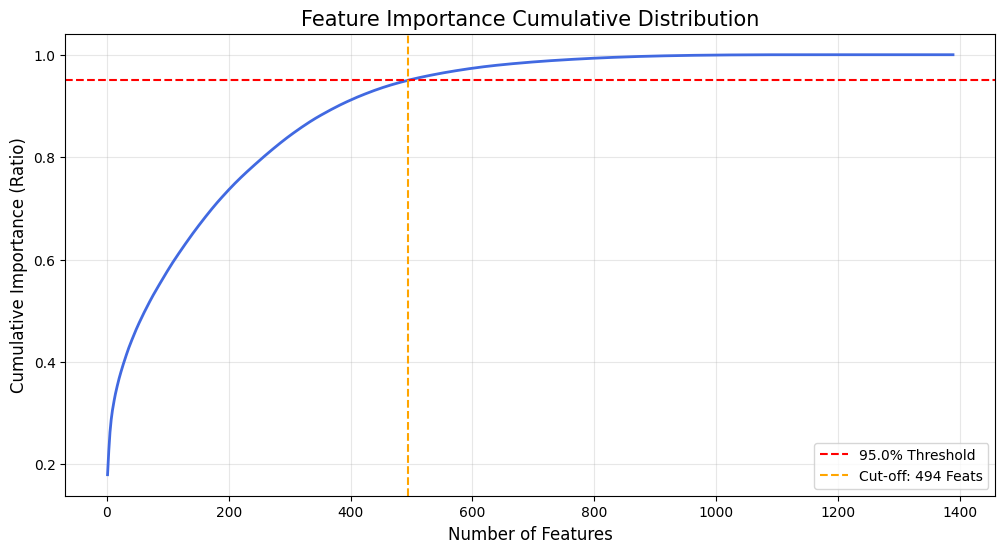

In [6]:
plt.figure(figsize=(12, 6))

# cumulative importance graph
plt.plot(range(1, len(fi_df) + 1), fi_df['Cum_Percentage'], color='royalblue', lw=2)

# 95% threshold
plt.axhline(y=threshold, color='red', linestyle='--', label=f'{threshold*100}% Threshold')
plt.axvline(x=important_features_count, color='orange', linestyle='--', label=f'Cut-off: {important_features_count} Feats')

plt.title('Feature Importance Cumulative Distribution', fontsize=15)
plt.xlabel('Number of Features', fontsize=12)
plt.ylabel('Cumulative Importance (Ratio)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [7]:
fi_df[fi_df['Importance'] == 0]

,Feature,Importance,Cum_Importance,Cum_Percentage
1121,prev_NAME_CASH_LOAN_PURPOSE_Payments_on_other_...,0.0,5.568700e+06,1.0
1122,prev_NAME_CASH_LOAN_PURPOSE_Money_for_a_third_...,0.0,5.568700e+06,1.0
1123,prev_NAME_CASH_LOAN_PURPOSE_Refusal_to_name_th...,0.0,5.568700e+06,1.0
1124,prev_NAME_CASH_LOAN_PURPOSE_Purchase_of_electr...,0.0,5.568700e+06,1.0
1125,prev_NAME_CASH_LOAN_PURPOSE_Gasification___wat...,0.0,5.568700e+06,1.0
...,...,...,...,...
1384,card_NAME_CONTRACT_STATUS_Demand_unique_std,0.0,5.568700e+06,1.0
1385,app_ORGANIZATION_TYPE_Culture,0.0,5.568700e+06,1.0
1386,card_NAME_CONTRACT_STATUS_Demand_unique_min,0.0,5.568700e+06,1.0
1387,app_ORGANIZATION_TYPE_Cleaning,0.0,5.568700e+06,1.0


기존의 대출 심사 베이스라인 모델은 신청자의 대출 상환 예측을 위해 1,400여개의 feature를 사용하고 있었습니다. 

Feature Importance(Gain) 분석을 통해 **상위 35%인 494개**의 핵심 피처만으로도 **기존 모델 설명력의 95%를 유지**할 수 있다는 점을 확인할 수 있었습니다. 

그렇지만 그 외 피처(895개)들은 모델 성능 향상에 미미하거나 기여도가 전혀 없었기에 오히려 학습 시간과 연산량만 늘리는 요인으로 생각했습니다. 이에 따라 기여도가 높은 494개의 피처만 활용하여 모델을 학습시키고, 기존 모델과 성능을 비교·분석해보았습니다.

기존 모델과 거의 비슷한 성능을 35%의 정보만을 가지고 구현 가능하다는 점은 **모델 운영에 필요한 데이터 저장 및 유지 보수 비용, 추론 속도**의 효율적인 개선 가능성을 보여주었습니다.

### 3. Reduced Model 성능 검증 실험

In [8]:
train = pd.read_csv("/Users/seunguk-lee/Desktop/my_project/HomeCreditDefault/venv_credit/data/train_full_cor.csv")
test = pd.read_csv("/Users/seunguk-lee/Desktop/my_project/HomeCreditDefault/venv_credit/data/test_full_cor.csv")
y = pd.read_csv("/Users/seunguk-lee/Desktop/my_project/HomeCreditDefault/venv_credit/data/y_full_cor.csv")

In [9]:
# selecting the top 494 features
suggested_top_494 = fi_df['Feature'][:494].tolist()

# feature filtering
existing_features = [f for f in suggested_top_494 if f in train.columns and f != "SK_ID_CURR"]

# data slicing
id_col = ["SK_ID_CURR"]
train_reduced = train[id_col + existing_features]
test_reduced  = test[id_col + existing_features]

# feature list update
features = existing_features

print(f"현재 데이터의 컬럼 중복 여부: {train_reduced.columns.duplicated().any()}")
print(f"최종 학습 피처 개수: {len(features)}")

현재 데이터의 컬럼 중복 여부: False
최종 학습 피처 개수: 482


피처 전처리 과정에서 중요한 피처로 선정된 상위 494개 중 11개가 현재 사용 중인 데이터셋에는 없는 것을 발견했습니다.

데이터 전처리 과정에서 버전 차이가 발생했거나, 범주형 변수의 인코딩 방식이 달라서 생긴 문제일 것이라 생각됩니다. 모델의 일관성을 유지하기 위해, 현재 데이터셋에 실제로 존재하는 483개의 피처만을 사용해 실험을 다시 구성하기로 했습니다.

In [10]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import gc
import warnings

# setting
warnings.filterwarnings("ignore")
seed = 42
num_folds = 5

if isinstance(y, pd.DataFrame):
    y_target = y["TARGET"] if "TARGET" in y.columns else y.iloc[:, 0]
else:
    y_target = y

# initializing
valid_aucs_cv = np.zeros(num_folds)
test_preds_cv  = np.zeros(len(test_reduced))
feature_importance_df = pd.DataFrame()

# CV 
folds = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=seed)

# LightGBM
gbm = lgb.LGBMClassifier(n_estimators     = 10000,
                         learning_rate    = 0.005,
                         num_leaves       = 70,
                         colsample_bytree = 0.8,
                         subsample        = 0.9,
                         max_depth        = 7,
                         reg_alpha        = 0.1,
                         reg_lambda       = 0.1,
                         min_split_gain   = 0.01,
                         min_child_weight = 2,
                         random_state     = seed,
                         n_jobs           = 10) # num_threads 대신 n_jobs 권장

from lightgbm import log_evaluation, early_stopping

print(f"학습 시작: 피처 개수 {len(features)}개, {num_folds} Folds 진행")

### CROSS-VALIDATION LOOP
for n_fold, (trn_idx, val_idx) in enumerate(folds.split(train_reduced, y_target)):
    
    # feature extraction
    trn_x, trn_y = train_reduced[features].iloc[trn_idx], y_target.iloc[trn_idx]
    val_x, val_y = train_reduced[features].iloc[val_idx], y_target.iloc[val_idx]
    
    # model training
    gbm.fit(trn_x, trn_y, 
            eval_set = [(trn_x, trn_y), (val_x, val_y)], 
            eval_metric = "auc",
            callbacks = [
                log_evaluation(period=500), 
                early_stopping(stopping_rounds=300)
            ])
    
    best_iter = gbm.best_iteration_
    
    # AUC calcultion
    valid_preds = gbm.predict_proba(val_x, num_iteration=best_iter)[:, 1]
    valid_aucs_cv[n_fold] = roc_auc_score(val_y, valid_preds)
    
    # Test
    test_preds_cv += gbm.predict_proba(test_reduced[features], num_iteration=best_iter)[:, 1] / num_folds 
    
    # Feature importance
    fold_importance_df = pd.DataFrame()
    fold_importance_df["Feature"] = features
    fold_importance_df["Importance"] = gbm.feature_importances_
    fold_importance_df["Fold"] = n_fold + 1
    feature_importance_df = pd.concat([feature_importance_df, fold_importance_df], axis=0)
    
    print("-" * 30)
    print(f"Fold {n_fold + 1} AUC: {valid_aucs_cv[n_fold]:.6f}")
    print("-" * 30)
    
    # memory clean
    del trn_x, trn_y, val_x, val_y
    gc.collect()
    
# final result
print(f"\n최종 Cross-Validation AUC score: {np.mean(valid_aucs_cv):.6f}")

학습 시작: 피처 개수 482개, 5 Folds 진행
[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.040767 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 107706
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 482
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482
Training until validation scores don't improve for 300 rounds
[500]	training's auc: 0.809038	training's binary_logloss: 0.232736	valid_1's auc: 0.766023	valid_1's binary_logloss: 0.244785
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

In [11]:
import joblib
import pickle
joblib.dump(existing_features, '/Users/seunguk-lee/Desktop/my_project/HomeCreditDefault/venv_credit/models/selected_features_483.pkl')

['/Users/seunguk-lee/Desktop/my_project/HomeCreditDefault/venv_credit/models/selected_features_483.pkl']

In [12]:
top_10_importance_sum = fi_df['Importance'][:10].sum()
total_importance_sum = fi_df['Importance'].sum()
top_10_ratio = (top_10_importance_sum / total_importance_sum) * 100

print(f'--- feature dominance analysis ---')
print(f'the top 10 features account for: {top_10_ratio:.2f}%')
print(f"the top 10 features make up: {10/1389:.2%}")

--- feature dominance analysis ---
the top 10 features account for: 31.25%
the top 10 features make up: 0.72%


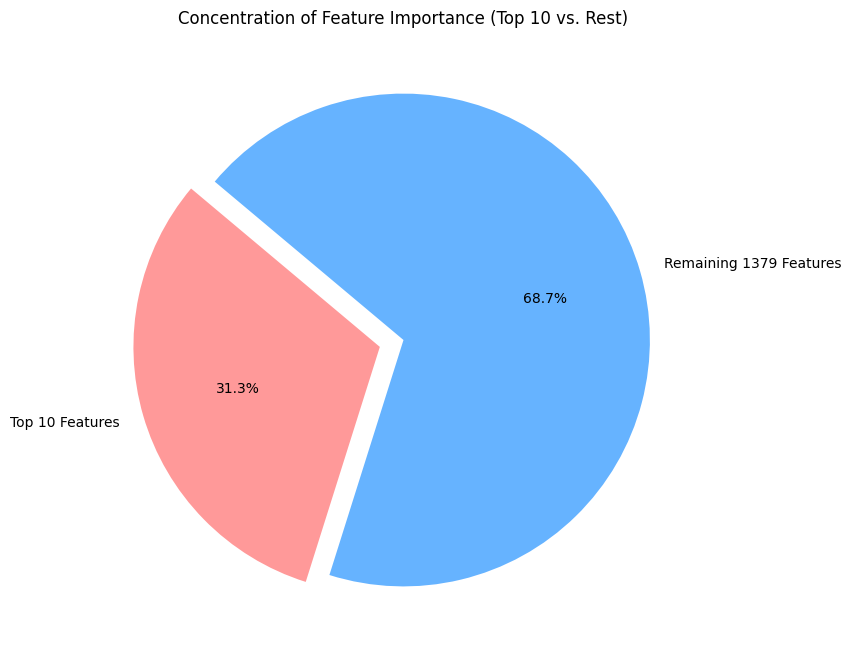

In [13]:
import matplotlib.pyplot as plt

# data preparation
labels = ['Top 10 Features', f'Remaining {len(fi_df)-10} Features']
sizes = [top_10_importance_sum, total_importance_sum - top_10_importance_sum]
colors = ['#ff9999', '#66b3ff']

plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors, explode=(0.1, 0))
plt.title('Concentration of Feature Importance (Top 10 vs. Rest)')
plt.show()

위 분석을 통해 아래의 인사이트들을 얻을 수 있었습니다.

1. 상위 10개의 피처가 모델 전체 영향력의 **약 1/3(31.3%)**을 차지하고 있었습니다. 특히 외부 신용평가 점수(EXT_SOURCE 시리즈) 등 소수의 피처가 대출 상환 예측에 강력한 설명력을 제공한다는 점을 확인할 수 있었습니다.

2. 피처를 10개에서 483개까지 확대했을 때 모델 설명력은 약 3배 정도만 증가했습니다. 즉, 초기 핵심 피처 이후 추가되는 많은 피처들의 기여도는 상대적으로 제한적이었으며, 이는 피처 수 증가가 항상 예측력 향상으로 이어지지 않는다는 점을 보여주었습니다.

3. 모델의 예측력이 특정 소수의 피처에 상당 부분 집중되어 있다는 사실도 발견했습니다. 이는 Credit Default를 이해하는 데 중요한 변수들을 파악하는 데 도움이 되었지만, 동시에 핵심 피처들의 데이터 품질이나 변화가 발생할 경우 모델 전체의 안정성이 영향을 받을 수 있다는 점을 시사합니다. 따라서 실제 운영 환경에서는 핵심 피처 중심의 모니터링 전략도 함께 고려할 필요가 있을 것 같습니다.

| 분석 단계       | 피처 수   | 피처 감소율 | 설명력 (Importance) | CV AUC    | 비고 |
|----------------|----------|------------|---------------------|-----------|------|
| Full Baseline  | 1,389개  | -          | 100%                | 0.792328  |      |
| Reduced Model  | 483개    | 65.2%      | 95.0%               | 0.788979  |      |
| Top 10 Core    | 10개     | 99.3%      | 31.25%              | -         |      |

핵심 인사이트
1. 일부 피처들에 집중된 영향력
- 전체 피처에서 **상위 10개**의 피처가 모델 전체 기여도에 **31.25%**를 차지하고 있음을 확인했습니다.
- **35%의 피처(483개)**만으로도 기존 모델 변별력의 **95%**까지 복원할 수 있었습니다. 

2. 자원의 효율적 활용 & 경량화 모델의 가능성 확인
- 기존 피처 수 대비 65% 이상 감소에도, AUC 성능 하락은 단 0.0033(0.4%) 수준으로 거의 같은 수준의 퍼포먼스를 보여줬습니다.
- 이러한 결과는 기존 모델과 거의 같은 수준의 성능을 가진 모델 학습을 적은 비용으로 가능함을 보여줬습니다.